In [27]:
import pandas as pd
df=pd.read_csv("train.csv")
df.head()


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [28]:
df.shape

(9800, 18)

In [29]:
df.columns.tolist()

['Row ID',
 'Order ID',
 'Order Date',
 'Ship Date',
 'Ship Mode',
 'Customer ID',
 'Customer Name',
 'Segment',
 'Country',
 'City',
 'State',
 'Postal Code',
 'Region',
 'Product ID',
 'Category',
 'Sub-Category',
 'Product Name',
 'Sales']

In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non-null   float64
dtypes: float

In [31]:
df.describe()

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [32]:
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


Data cleaning

In [33]:
df['Order Date']= pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']= pd.to_datetime(df['Ship Date'], dayfirst=True)
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


 Fix missing Postal Code:

In [34]:
df['Postal Code']= df['Postal Code'].fillna(0)
print(df['Postal Code'].isnull().sum())

0


Check Duplicate

In [35]:
print('Duplicated', df.duplicated().sum())
df=df.drop_duplicates()
print("after removing duplicate", df.shape)

Duplicated 0
after removing duplicate (9800, 18)


Exploratory Data Analysis (EDA)

In [36]:
#Question 1 — Which Region has highest Sales?
region_sales=df.groupby('Region')['Sales'].sum().sort_values(ascending=False)
print(region_sales)

Region
West       710219.6845
East       669518.7260
Central    492646.9132
South      389151.4590
Name: Sales, dtype: float64


In [37]:
#Question 2 — Which Category sells the most?
category_sales=df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print(category_sales)

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


In [38]:
#Question 3 — Which Sub-Category has highest Sales?
sub_category_sales=df.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False)
print(sub_category_sales)

Sub-Category
Phones         327782.4480
Chairs         322822.7310
Storage        219343.3920
Tables         202810.6280
Binders        200028.7850
Machines       189238.6310
Accessories    164186.7000
Copiers        146248.0940
Bookcases      113813.1987
Appliances     104618.4030
Furnishings     89212.0180
Paper           76828.3040
Supplies        46420.3080
Art             26705.4100
Envelopes       16128.0460
Labels          12347.7260
Fasteners        3001.9600
Name: Sales, dtype: float64


In [39]:
#Question 4 — Which Segment brings most Sales?
Segment_sales=df.groupby('Segment')['Sales'].sum().sort_values(ascending=False)
print(Segment_sales)

Segment
Consumer       1.148061e+06
Corporate      6.884941e+05
Home Office    4.249822e+05
Name: Sales, dtype: float64


In [40]:
#Question 5 — Monthly Sales Trend
df['Months']=df['Order Date'].dt.month
monthly_sales=df.groupby('Months')['Sales'].sum()
print(monthly_sales)

Months
1      94291.6296
2      59371.1154
3     197573.5872
4     136283.0006
5     154086.7237
6     145837.5233
7     145535.6890
8     157315.9270
9     300103.4117
10    199496.2947
11    350161.7110
12    321480.1695
Name: Sales, dtype: float64


In [41]:
#Question 6 — Which State has highest Sales?
state_sales=df.groupby('State')['Sales'].sum().sort_values(ascending=False).head(10)
print(state_sales)


State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


In [42]:
#Question 7 — Which Ship Mode is most used?
ship_mode=df['Ship Mode'].value_counts()
print(ship_mode)

Ship Mode
Standard Class    5859
Second Class      1902
First Class       1501
Same Day           538
Name: count, dtype: int64


In [43]:
#Question 8 — Yearly Sales Trend
df['Years']=df['Order Date'].dt.year
yearly_sales=df.groupby("Years")['Sales'].sum()
print(yearly_sales)

Years
2015    479856.2081
2016    459436.0054
2017    600192.5500
2018    722052.0192
Name: Sales, dtype: float64


Visualization

/tmp/ipykernel_3650/1308054756.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set2')


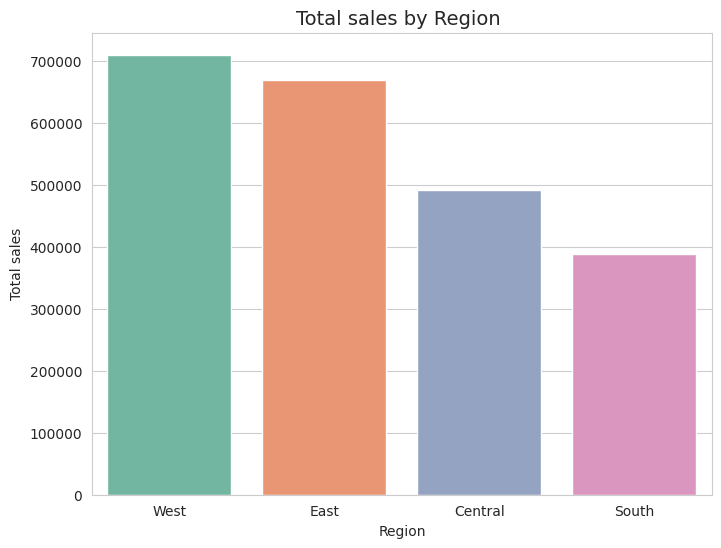

In [44]:
#Chart 1 — Region Sales Bar Chart
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")
plt.figure(figsize=(8,6))
sns.barplot(x=region_sales.index, y=region_sales.values, palette='Set2')
plt.title("Total sales by Region ", fontsize=14)
plt.xlabel('Region')
plt.ylabel('Total sales')
plt.show()

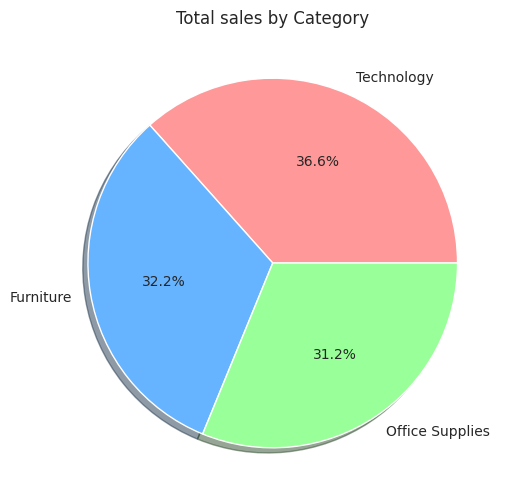

In [45]:
#Chart 2 — Category Sales Pie Chart
plt.figure(figsize=(8,6))
plt.pie(category_sales, labels=category_sales.index, autopct='%1.1f%%', colors=["#ff9999", "#66b3ff", "#99ff99"], shadow=True)
plt.title('Total sales by Category')
plt.show()

/tmp/ipykernel_3650/2013002323.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sub_category_sales.index, y=sub_category_sales.values, palette="Blues_r")


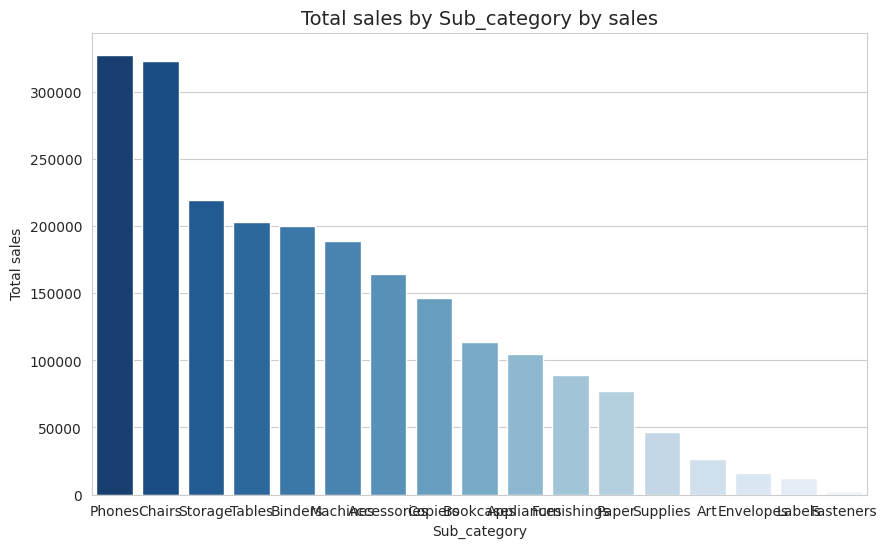

In [46]:
#Chart 3 — Sub Category Bar Chart
plt.figure(figsize=(10,6))
sns.barplot(x=sub_category_sales.index, y=sub_category_sales.values, palette="Blues_r")
plt.title("Total sales by Sub_category by sales", fontsize=14)
plt.xlabel('Sub_category')
plt.ylabel('Total sales')
plt.show()

/tmp/ipykernel_3650/1899740691.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=Segment_sales.index, y=Segment_sales.values, palette="Set1")


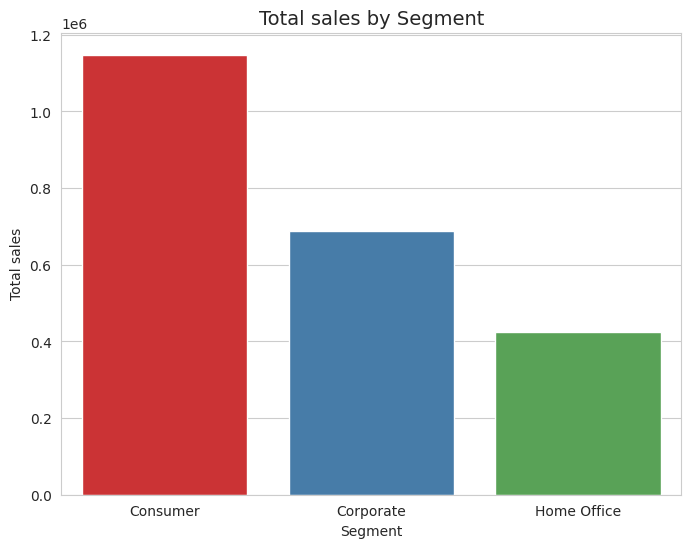

In [47]:
#Chart 4 — Segment Sales Bar Chart
plt.figure(figsize=(8,6))
sns.barplot(x=Segment_sales.index, y=Segment_sales.values, palette="Set1")
plt.title("Total sales by Segment", fontsize=14)
plt.xlabel('Segment')
plt.ylabel('Total sales')
plt.show()

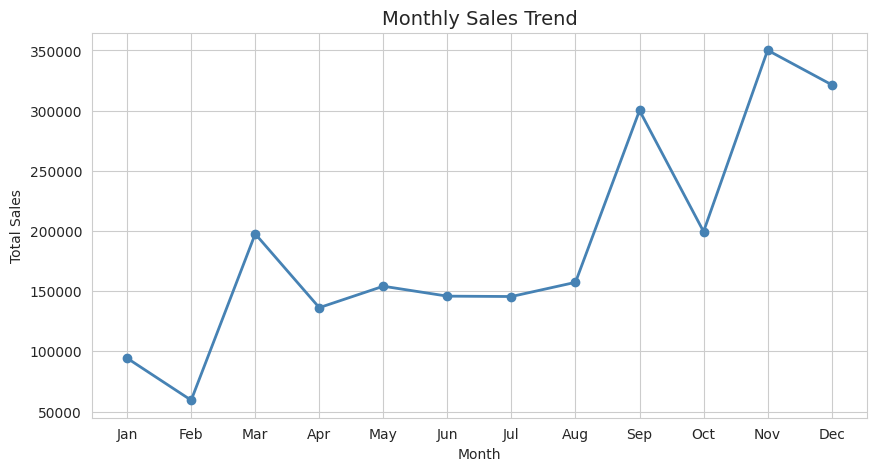

In [48]:
#Chart 5 — Monthly Sales Line Chart
plt.figure(figsize=(10, 5))
plt.plot(monthly_sales.index, monthly_sales.values,
         color="steelblue", marker="o", linewidth=2)
plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Total Sales")
plt.xticks(range(1, 13), #This function controls what appears on the X axis
           ["Jan","Feb","Mar","Apr","May","Jun",
            "Jul","Aug","Sep","Oct","Nov","Dec"])
plt.grid(True)
plt.show()

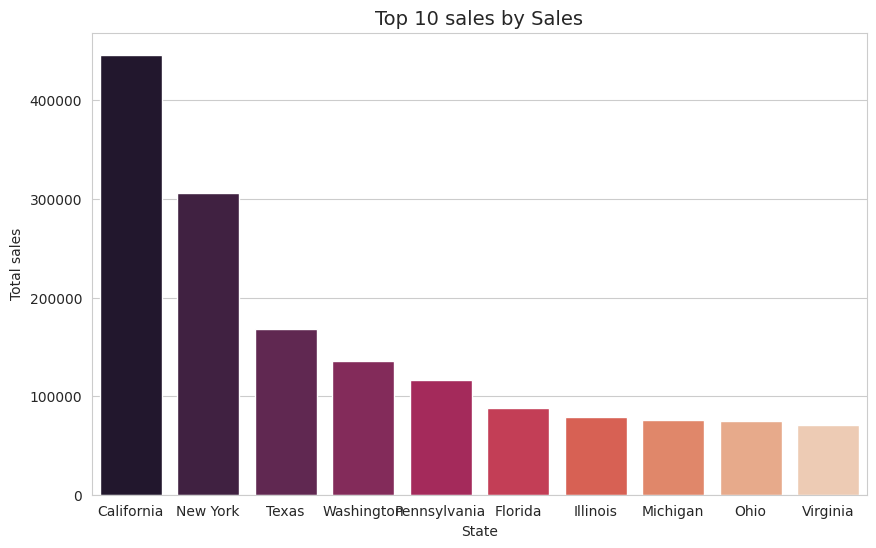

In [49]:
#Chart 6 — Top 10 States
plt.figure(figsize=(10, 6))
sns.barplot(x=state_sales.index, y=state_sales.values, hue=state_sales.index, palette="rocket")
plt.title("Top 10 sales by Sales", fontsize=14)
plt.xlabel('State')
plt.ylabel('Total sales')
plt.show()

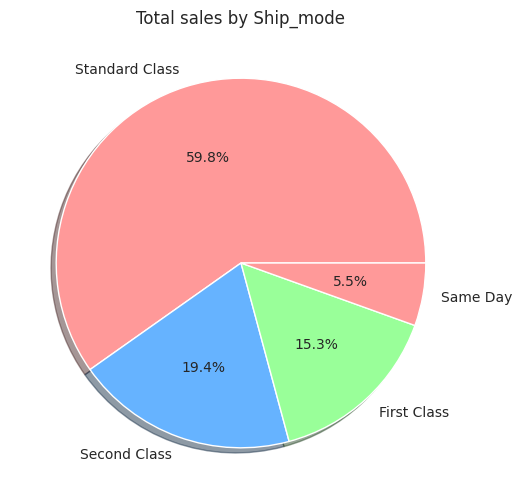

In [50]:
#Chart 7 — Ship Mode Pie Chart
plt.figure(figsize=(8,6))
plt.pie(ship_mode, labels=ship_mode.index, autopct='%1.1f%%', colors=["#ff9999", "#66b3ff", "#99ff99"], shadow=True)
plt.title('Total sales by Ship_mode')
plt.show()

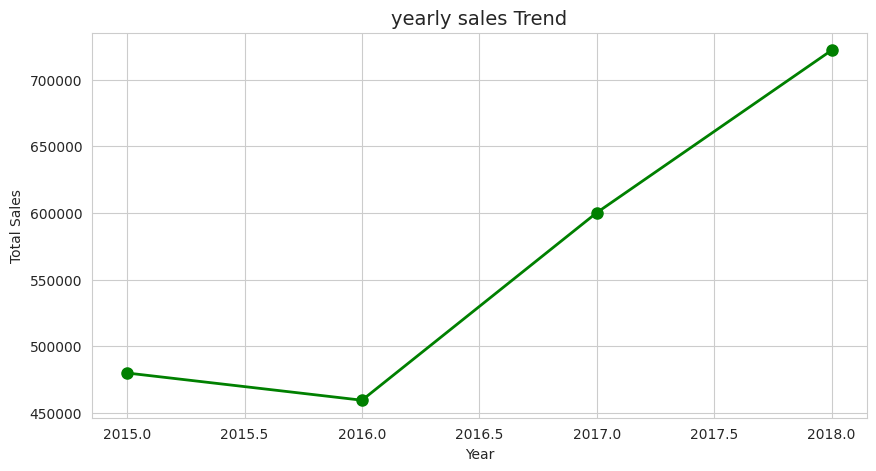

In [51]:
#Chart 8 — Yearly Sales Line Chart
plt.figure(figsize=(10,5))
plt.plot(yearly_sales.index, yearly_sales.values, color='green', marker='o', linewidth=2, markersize=8)
plt.title('yearly sales Trend', fontsize=14)
plt.xlabel('Year')
plt.ylabel("Total Sales")
plt.grid(True)
plt.show()